In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast


# Load the CSV file
df = pd.read_csv("results/Branin_Random-Search.csv")

# Show the first few rows
print(df.head())


  function_name  transform_id         method  seed  iteration         y  \
0        Branin             0  Random-Search     0          0  0.148900   
1        Branin             0  Random-Search     0          1  0.153490   
2        Branin             0  Random-Search     0          2  0.028412   
3        Branin             0  Random-Search     0          3  0.094710   
4        Branin             0  Random-Search     0          4  0.516777   

                         x  
0  [0.5488135  0.71518937]  
1  [0.60276338 0.54488318]  
2  [0.4236548  0.64589411]  
3  [0.43758721 0.891773  ]  
4  [0.96366276 0.38344152]  


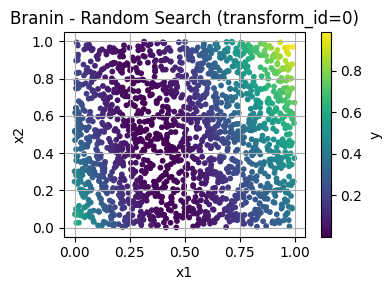

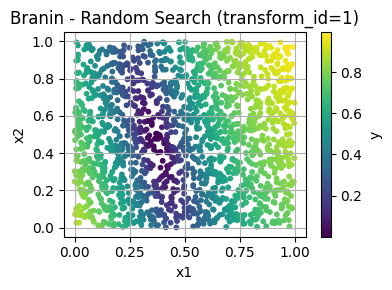

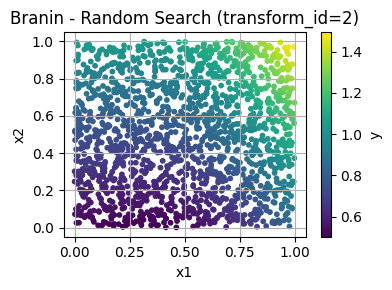

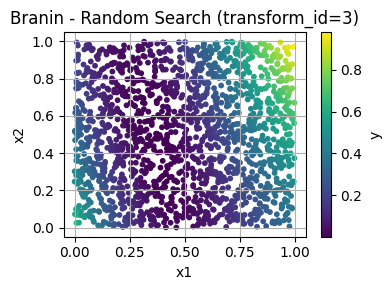

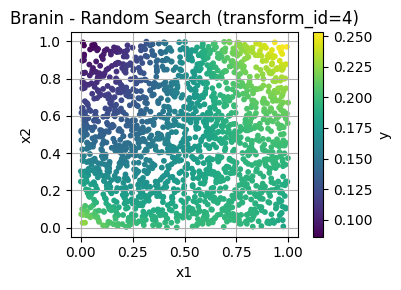

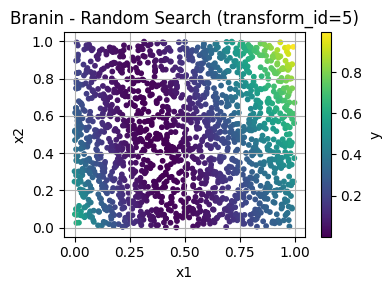

In [19]:
# Parse 'x' column
df['x_parsed'] = df['x'].apply(lambda s: np.fromstring(s.strip('[]'), sep=' '))
df['x1'] = df['x_parsed'].apply(lambda arr: arr[0])
df['x2'] = df['x_parsed'].apply(lambda arr: arr[1])

# Plot for each transform_id
unique_transforms = df['transform_id'].unique()

for transform_id in unique_transforms:
    df_subset = df[df['transform_id'] == transform_id]
    
    plt.figure(figsize=(4, 3))
    sc = plt.scatter(df_subset['x1'], df_subset['x2'], c=df_subset['y'], cmap='viridis', s=10)
    plt.colorbar(sc, label='y')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(f'Branin - Random Search (transform_id={transform_id})')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

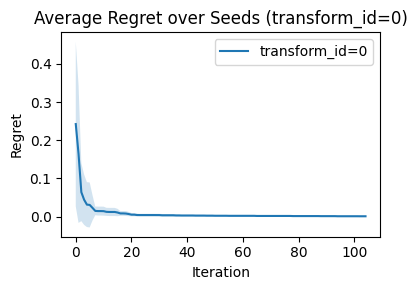

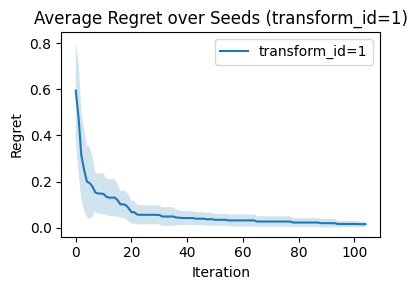

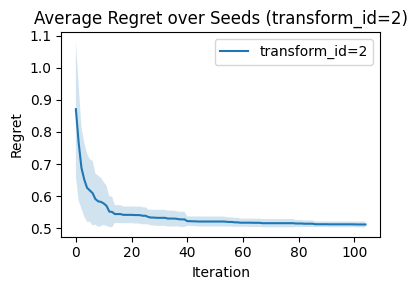

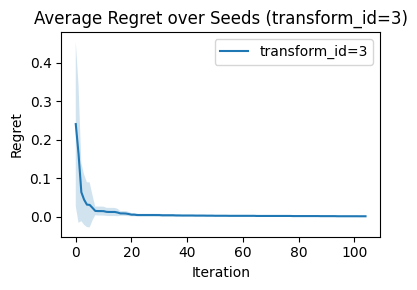

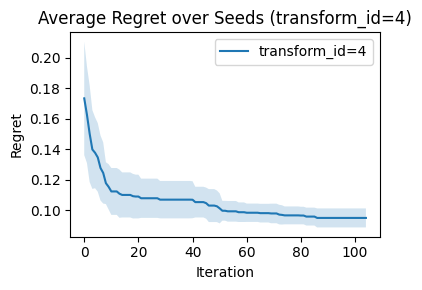

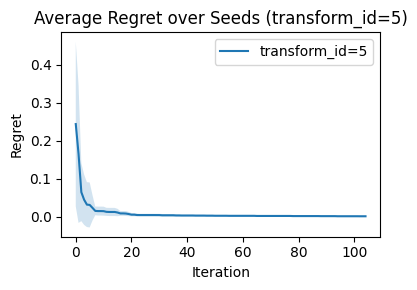

In [21]:

# Compute global optimum y* across all data
y_star = df['y'].min()

# Prepare plot per transform_id
for transform_id in df['transform_id'].unique():
    df_t = df[df['transform_id'] == transform_id]

    pivot = df_t.pivot(index='iteration', columns='seed', values='y')
    pivot = pivot.sort_index()
    incumbent = pivot.cummin()
    regret = incumbent - y_star
    mean_regret = regret.mean(axis=1)
    std_regret = regret.std(axis=1)

    # Plot
    plt.figure(figsize=(4, 3))
    plt.plot(mean_regret.index, mean_regret.values, label=f'transform_id={transform_id}')
    plt.fill_between(mean_regret.index,
                     mean_regret - std_regret,
                     mean_regret + std_regret,
                     alpha=0.2)
    plt.xlabel("Iteration")
    plt.ylabel("Regret")
    plt.title(f"Average Regret over Seeds (transform_id={transform_id})")
    plt.tight_layout()
    plt.legend()
    plt.show()